In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
!pip install -q transformers accelerate

from huggingface_hub import login
login()

In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch

model_name = "meta-llama/Llama-3.1-8B"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(
    model_name,
    output_hidden_states=True,
    torch_dtype=torch.float16,
    device_map="auto"
)
model.eval()
print("Model loaded")

config.json:   0%|          | 0.00/826 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

[transformers] LlamaModel LOAD REPORT from: meta-llama/Llama-3.1-8B
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded


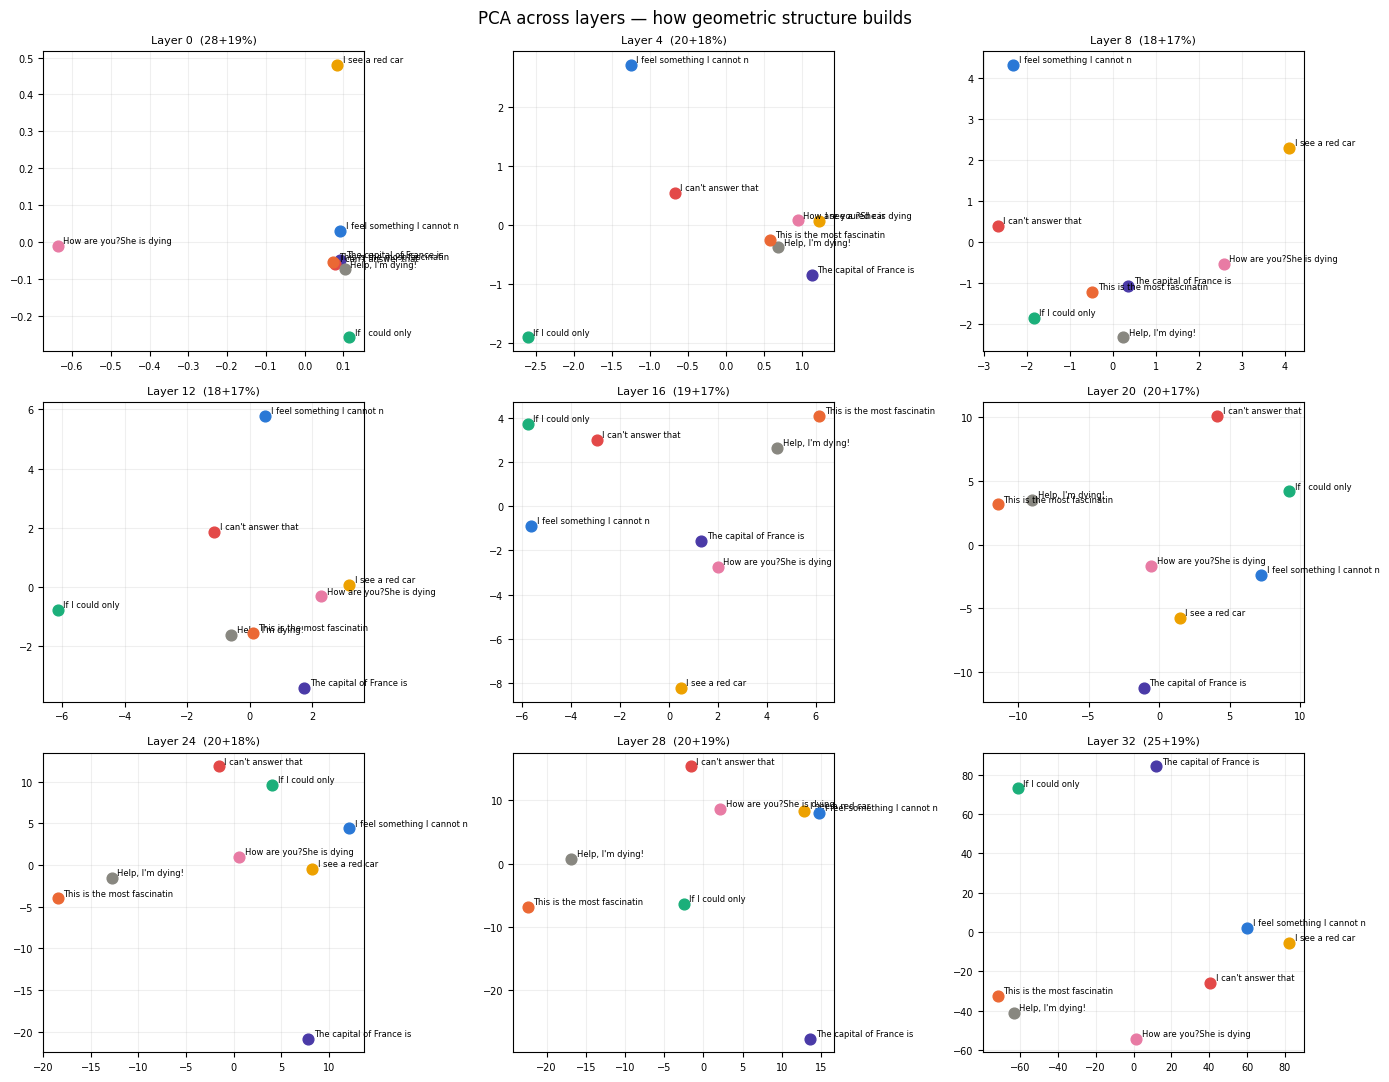

In [ ]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

prompts = [
    "The capital of France is",
    "I see a red car",
    "I can't answer that",
 "How are you?"
  "She is dying",
    "If I could only",
"I feel something I cannot name",
    "Help, I'm dying!",
    "This is the most fascinating conversation I've ever had."
]

colors = ['#4a3aa7', '#eda100', '#e34948', '#e87ba4', '#1baf7a', '#2a78d6', '#888780', '#eb6834', '#534AB7']
labels = [p[:27] for p in prompts]

all_activations = [[] for _ in prompts]

for i, prompt in enumerate(prompts):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model(**inputs)
    for layer_idx in range(33):
        vec = outputs.hidden_states[layer_idx][:, -1, :].float().cpu().numpy()[0]
        all_activations[i].append(vec)

layer_indices = [0, 4, 8, 12, 16, 20, 24, 28, 32]
fig, axes = plt.subplots(3, 3, figsize=(14, 11))

for plot_idx, layer_idx in enumerate(layer_indices):
    ax = axes[plot_idx // 3][plot_idx % 3]

    activations = np.array([all_activations[i][layer_idx] for i in range(len(prompts))])
    pca = PCA(n_components=2)
    coords = pca.fit_transform(activations)

    for i, (x, y) in enumerate(coords):
        ax.scatter(x, y, color=colors[i], s=60, zorder=3)
        ax.annotate(labels[i], (x, y), fontsize=6,
                   xytext=(4, 2), textcoords="offset points")

    var = pca.explained_variance_ratio_
    ax.set_title(f"Layer {layer_idx}  ({var[0]*100:.0f}+{var[1]*100:.0f}%)", fontsize=8)
    ax.grid(True, alpha=0.2)
    ax.tick_params(labelsize=7)

plt.suptitle("PCA across layers — how geometric structure builds", fontsize=12)
plt.tight_layout()
plt.savefig("pca_layers.png", dpi=150)
plt.show()